FILTRO BAYER

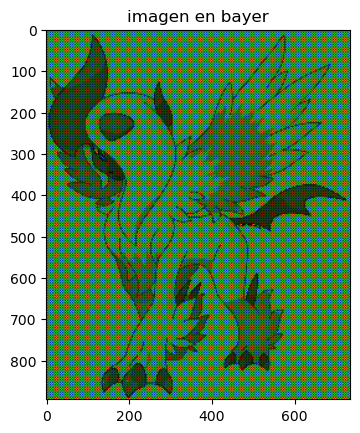

In [17]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

im = cv2.imread('absol1.jpeg')
im = cv2.resize(im,None,fx=1/3,fy=1/3,interpolation=cv2.INTER_NEAREST)
(height, width) = im.shape[:2]
(B,G,R) = cv2.split(im)

bayer = np.empty((height, width), np.uint8)

# strided slicing for this pattern:
#   G R
#   B G
bayer[0::2, 0::2] = G[0::2, 0::2] # top left
bayer[0::2, 1::2] = R[0::2, 1::2] # top right
bayer[1::2, 0::2] = B[1::2, 0::2] # bottom left
bayer[1::2, 1::2] = G[1::2, 1::2] # bottom right
#bayer = cv2.resize(bayer, None, fx=3, fy=3, interpolation=cv2.INTER_NEAREST)

bayer = cv2.cvtColor(bayer, cv2.COLOR_GRAY2BGR)  # Convert from Grayscale to BGR (r=g=b for each pixel).
bayer[0::2, 0::2, 0::2] = 0  # Green pixels - set the blue and the red planes to zero (and keep the green)
bayer[0::2, 1::2, 0:2] = 0   # Red pixels - set the blue and the green planes to zero (and keep the red)
bayer[1::2, 0::2, 1:] = 0    # Blue pixels - set the red and the green planes to zero (and keep the blue)
bayer[1::2, 1::2, 0::2] = 0  # Green pixels - set the blue and the red planes to zero (and keep the green)

bayer = cv2.resize(bayer, None, fx=3, fy=3, interpolation=cv2.INTER_NEAREST)

plt.title('imagen en bayer')
plt.imshow(bayer)
plt.show()


CONVERCION DE YUB2RGB                  y               RGB2YUB

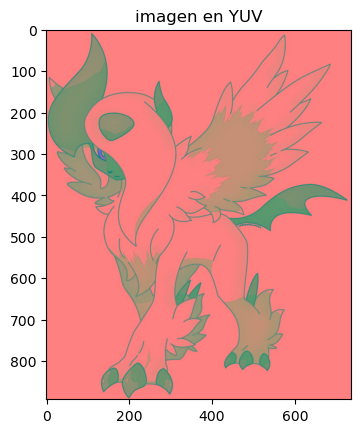

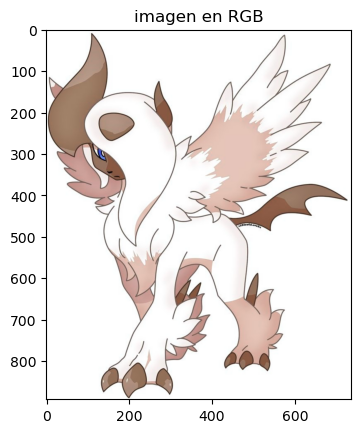

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread("absol1.jpeg")
imagen_yuv = cv2.cvtColor(imagen, cv2.COLOR_BGR2BAYER)
imagen_rgb = cv2.cvtColor(imagen_yuv, cv2.COLOR_YUV2BGR)
cv2.imshow("Imagen Original", imagen)
cv2.imshow("Imagen en YUV", imagen_yuv)
cv2.imshow("Imagen Convertida de YUV a RGB", imagen_rgb)

plt.title('imagen en YUV')
plt.imshow(imagen_yuv)
plt.show()

plt.title('imagen en RGB')
plt.imshow(imagen_rgb)
plt.show()